In [73]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
# Some ploting setup
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12)
fonttitle=18
fontlabel=12
savefig=True

In [74]:
with np.load('../specfem2d_examples/seam/data_specfem_seam.npz') as data:
    vx_specfem = data['vx']
    vz_specfem = data['vz']
    dt_specfem = data['dt']
with np.load('../devito_examples/seam/data_devito_seam.npz') as data:
    vx_devito = data['vx']
    vz_devito = data['vz']
    dt_devito = data['dt']

In [75]:
# normalized trace by trace
# vx_specfem = -vx_specfem / np.max(np.abs(vx_specfem), axis=0)
# vz_specfem = vz_specfem / np.max(np.abs(vz_specfem), axis=0)
vx_specfem *= -1/np.max(np.abs(vx_specfem))
vz_specfem *=  1/np.max(np.abs(vz_specfem))
vx_specfem.shape

(21430, 401)

In [76]:
time_specfem = np.arange(vx_specfem.shape[0]) * dt_specfem
time_devito = np.arange(vx_devito.shape[0]) * dt_devito * 1e-3  # Convert ms to s

# Use time specfem as reference
# Interpolate Devito data to Specfem time grid using scipy interp
from scipy.interpolate import interp1d

interp_vx = interp1d(time_devito, vx_devito, axis=0, kind='linear', bounds_error=False,fill_value=0.0)
interp_vz = interp1d(time_devito, vz_devito, axis=0, kind='linear', bounds_error=False, fill_value=0.0)
vx_devito_interp = interp_vx(time_specfem) 
vz_devito_interp = interp_vz(time_specfem) 
# Compute time shift in trace at 50m
from scipy.signal import correlate, correlation_lags
trace = 200
corrz = correlate(vz_devito_interp[:, trace], vz_specfem[:, trace], mode='full')
corrx = correlate(vx_devito_interp[:, trace], vx_specfem[:, trace], mode='full')
lagsx = correlation_lags(len(vx_devito_interp[:, trace]), len(vx_specfem[:, trace]), mode='full')  # misma longitud que corr
dtx = time_specfem[1] - time_specfem[0]
time_shiftx = lagsx[np.argmax(corrx)] * dtx
lagsz = correlation_lags(len(vz_devito_interp[:, trace]), len(vz_specfem[:, trace]), mode='full')  # misma longitud que corr
dtz = time_specfem[1] - time_specfem[0]
time_shiftz = lagsz[np.argmax(corrz)] * dtz
time_shift = (time_shiftx + time_shiftz) / 2.0
print(f'Time shift between Devito and Analytic at trace {trace}: {time_shift:.4f} s')
# Apply time shift
time_specfem_shifted_x = time_specfem + time_shiftx
time_specfem_shifted_z = time_specfem + time_shiftz
vx_devito_interp = interp_vx(time_specfem_shifted_x) 
vz_devito_interp = interp_vz(time_specfem_shifted_z)
# Trace by trace amplitude correction with dot product (trace by trace)
amplitude_correction_x = np.sum(vx_specfem * vx_devito_interp, axis=0) / np.sum(vx_devito_interp * vx_devito_interp, axis=0)
amplitude_correction_z = np.sum(vz_specfem * vz_devito_interp, axis=0) / np.sum(vz_devito_interp * vz_devito_interp, axis=0)
vx_devito_interp = vx_devito_interp * amplitude_correction_x
vz_devito_interp = vz_devito_interp * amplitude_correction_z

Time shift between Devito and Analytic at trace 200: -0.0193 s


In [77]:
# time_specfem = np.arange(vx_specfem.shape[0]) * dt_specfem
# time_devito = np.arange(vx_devito.shape[0]) * dt_devito * 1e-3  # Convert ms to s

# # Use time specfem as reference
# # Interpolate Devito data to Specfem time grid using scipy interp
# from scipy.interpolate import interp1d
# time_shift = 0.019  # seconds
# interp_vx = interp1d(time_devito+time_shift, vx_devito, axis=0, kind='cubic', fill_value='extrapolate')
# interp_vz = interp1d(time_devito+time_shift, vz_devito, axis=0, kind='cubic', fill_value='extrapolate')
# vx_devito_interp = interp_vx(time_specfem) 
# vz_devito_interp = interp_vz(time_specfem) 
# # Trace by trace amplitude correction with dot product (trace by trace)
# amplitude_correction_x = np.sum(vx_specfem * vx_devito_interp, axis=0) / np.sum(vx_devito_interp * vx_devito_interp, axis=0)
# amplitude_correction_z = np.sum(vz_specfem * vz_devito_interp, axis=0) / np.sum(vz_devito_interp * vz_devito_interp, axis=0)
# vx_devito_interp = vx_devito_interp * amplitude_correction_x
# vz_devito_interp = vz_devito_interp * amplitude_correction_z

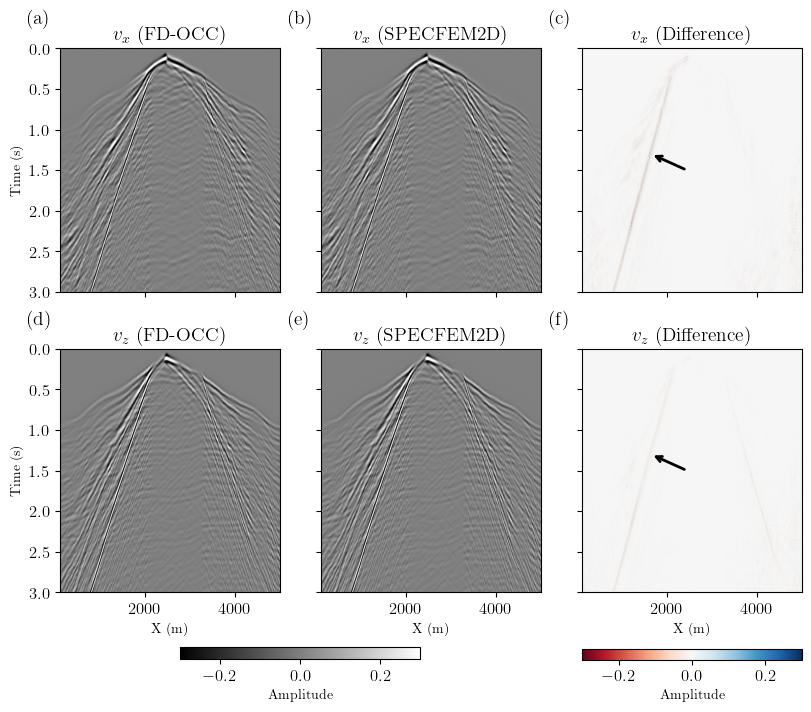

In [78]:
# Shot gather error of normalized traces
vx_shot_error = vx_devito_interp - vx_specfem
vz_shot_error = vz_devito_interp - vz_specfem   
# pcx=np.max(np.abs(vx_specfem))
# pcz=np.max(np.abs(vz_specfem))
pcx = 0.3
pcz = 0.3
pcxdif = pcx
pczdif = pcz
#pcxdif = pcx
#pczdif = pcz
xmin=120
xmax=5000
from devitocurvilinear import odt_seismics
cmap = 'gray'
cmapdif = 'RdBu'
extent = [xmin, xmax, time_specfem[-1], time_specfem[0]]
fig1, ax = plt.subplots(2, 3, layout='constrained', sharey=True, sharex=True, figsize=(8,7))
# VX
ax[0,0].set_title('$v_x$ (FD-OCC)', fontsize=14)
imx1=ax[0,0].imshow(vx_devito_interp, cmap=cmap, vmin=-pcx, vmax=pcx, origin='upper', aspect='auto',
           extent=extent)
ax[0,0].set_ylabel('Time (s)')
ax[0,1].set_title('$v_x$ (SPECFEM2D)', fontsize=14)
imx2=ax[0,1].imshow(vx_specfem, cmap=cmap, vmin=-pcx, vmax=pcx, origin='upper', aspect='auto',
           extent=extent)
ax[0,2].set_title('$v_x$ (Difference)', fontsize=14)
imx3 = ax[0,2].imshow(vx_devito_interp - vx_specfem, cmap=cmapdif, vmin=-pcxdif, vmax=pcxdif, origin='upper', aspect='auto',
           extent=extent)
# VZ
ax[1,0].set_title('$v_z$ (FD-OCC)', fontsize=14)
imv1=ax[1,0].imshow(vz_devito_interp, cmap=cmap, vmin=-pcz, vmax=pcz, origin='upper', aspect='auto',
           extent=extent)
ax[1,0].set_ylabel('Time (s)')
ax[1,0].set_xlabel('X (m)')
ax[1,1].set_title('$v_z$ (SPECFEM2D)', fontsize=14)
imv2=ax[1,1].imshow(vz_specfem, cmap=cmap, vmin=-pcz, vmax=pcz, origin='upper', aspect='auto',
           extent=extent)
ax[1,1].set_xlabel('X (m)')
fig1.colorbar(imv2, ax=ax[1,:2], orientation='horizontal', pad=0.04, shrink=0.5, label='Amplitude')
ax[1,2].set_title('$v_z$ (Difference)', fontsize=14)
imv3 = ax[1,2].imshow(vz_devito_interp - vz_specfem, cmap=cmapdif, vmin=-pczdif, vmax=pczdif, origin='upper', aspect='auto',
           extent=extent)
fig1.colorbar(imv3, ax=ax[:,2], orientation='horizontal', pad=0.02, label='Amplitude')
ax[1,2].set_xlabel('X (m)')

ax[0,2].annotate("", xy=(1650, 1.3), xytext=(1650+800, 1.5),arrowprops=dict(arrowstyle="->", color='black',lw=2))
ax[1,2].annotate("", xy=(1650, 1.3), xytext=(1650+800, 1.5),arrowprops=dict(arrowstyle="->", color='black',lw=2))

ax[0,0].text(-0.15, 1.1, '(a)', fontsize=14, transform=ax[0,0].transAxes)
ax[0,1].text(-0.15, 1.1, '(b)', fontsize=14, transform=ax[0,1].transAxes)
ax[0,2].text(-0.15, 1.1, '(c)', fontsize=14, transform=ax[0,2].transAxes)
ax[1,0].text(-0.15, 1.1, '(d)', fontsize=14, transform=ax[1,0].transAxes)
ax[1,1].text(-0.15, 1.1, '(e)', fontsize=14, transform=ax[1,1].transAxes)
ax[1,2].text(-0.15, 1.1, '(f)', fontsize=14, transform=ax[1,2].transAxes)

if savefig:
    fig1.savefig('seam_shotgather_comparison.pdf', bbox_inches='tight', transparent=True)
    fig1.savefig('seam_shotgather_comparison.png', bbox_inches='tight', transparent=True)

In [79]:
import matplotlib
print(matplotlib.__version__)


3.10.6


In [80]:
pczdif

0.3

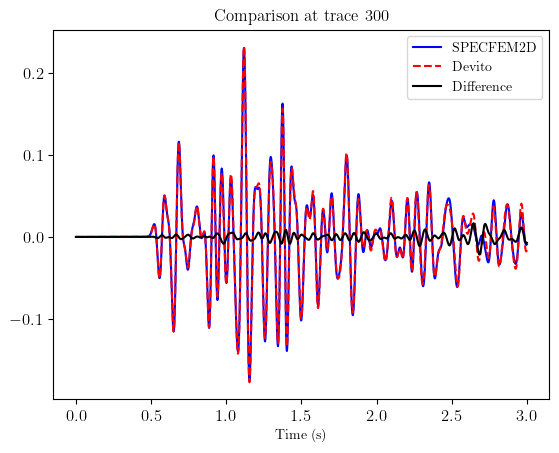

In [81]:
trace = 300
plt.plot(time_specfem, vx_specfem[:, trace], label='SPECFEM2D', color='blue')
plt.plot(time_specfem, vx_devito_interp[:, trace], label='Devito', color='red', linestyle='--')
plt.plot(time_specfem, vx_devito_interp[:, trace]-vx_specfem[:, trace], label='Difference', color='black')
plt.xlabel('Time (s)')
plt.title(f'Comparison at trace {trace}')
plt.legend()
plt.show()

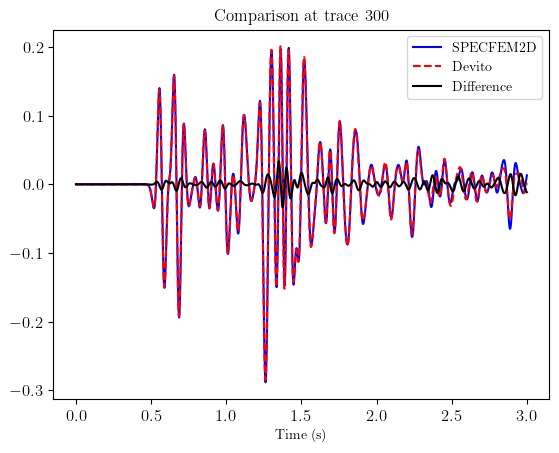

In [82]:
plt.plot(time_specfem, vz_specfem[:, trace], label='SPECFEM2D', color='blue')
plt.plot(time_specfem, vz_devito_interp[:, trace], label='Devito', color='red', linestyle='--')
plt.plot(time_specfem, vz_devito_interp[:, trace]-vz_specfem[:, trace], label='Difference', color='black')
plt.xlabel('Time (s)')
plt.title(f'Comparison at trace {trace}')
plt.legend()
plt.show()

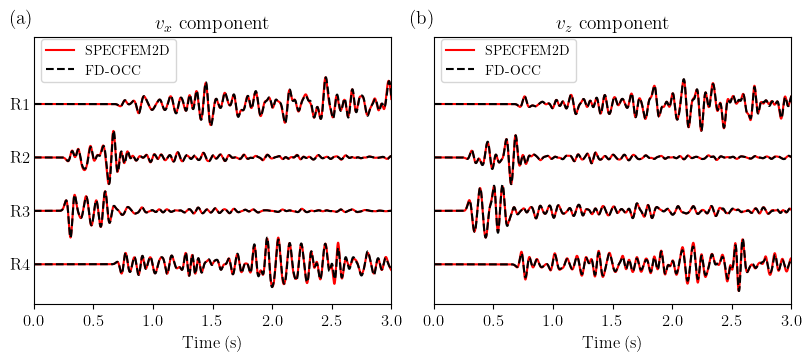

In [83]:
fig, ax = plt.subplots(1, 2, layout='constrained', sharey=True, figsize=(8, 3.5))
bias=0.0
for trace in [50,150,250,350]:
    vx_devito_trace = vx_devito_interp[:, trace]/np.max(np.abs(vx_devito_interp[:, trace]))
    vz_devito_trace = vz_devito_interp[:, trace]/np.max(np.abs(vz_devito_interp[:, trace]))
    vx_specfem_trace = vx_specfem[:, trace]/np.max(np.abs(vx_specfem[:, trace]))
    vz_specfem_trace = vz_specfem[:, trace]/np.max(np.abs(vz_specfem[:, trace]))
# --- IGNORE ---
    bias -=  2  # for better visualization
    ax[0].plot(time_specfem, vx_devito_trace + bias, label='Devito', color='red', linestyle='-')
    ax[0].plot(time_specfem, vx_specfem_trace + bias, label='Specfem', color='black', linestyle='--')
    ax[1].plot(time_specfem, vz_devito_trace + bias, label='Devito', color='red', linestyle='-')
    ax[1].plot(time_specfem, vz_specfem_trace + bias, label='Specfem', color='black', linestyle='--')

ax[0].set_title('$v_x$ component', fontsize=14)
ax[1].set_title('$v_z$ component', fontsize=14)
ax[0].set_xlim(0, 3.0)
ax[0].set_ylim(-9.5, 0.5)
ax[1].set_xlim(0, 3.0)
ax[0].legend(['SPECFEM2D', 'FD-OCC'], fontsize=10, loc='upper left', bbox_to_anchor=(0.0, 1.018))
ax[1].legend(['SPECFEM2D', 'FD-OCC'], fontsize=10, loc='upper left', bbox_to_anchor=(0.0, 1.018))
ax[0].set_xlabel('Time (s)', fontsize=12)
ax[1].set_xlabel('Time (s)', fontsize=12)
ax[0].text(-0.2, -2.2, 'R1', fontsize=12)
ax[0].text(-0.2, -2.2-2, 'R2', fontsize=12)
ax[0].text(-0.2, -2.2-2*2, 'R3', fontsize=12)
ax[0].text(-0.2, -2.2-2*3, 'R4', fontsize=12)
ax[0].text(-0.2, 1.0, '(a)', fontsize=14)
ax[1].text(-0.2, 1.0, '(b)', fontsize=14)
ax[0].set_yticks([])
if savefig:
    fig.savefig('seam_traces_comparison.pdf', bbox_inches='tight', transparent=True)
    fig.savefig('seam_traces_comparison.png', bbox_inches='tight', transparent=True)

In [84]:
for trace in [50,150,250,350]:
    vx_devito_trace = vx_devito_interp[:, trace]/np.max(np.abs(vx_devito_interp[:, trace]))
    vz_devito_trace = vz_devito_interp[:, trace]/np.max(np.abs(vz_devito_interp[:, trace]))
    vx_specfem_trace = vx_specfem[:, trace]/np.max(np.abs(vx_specfem[:, trace]))
    vz_specfem_trace = vz_specfem[:, trace]/np.max(np.abs(vz_specfem[:, trace]))

    # L2 relative error
    error_vx = np.linalg.norm(vx_devito_trace - vx_specfem_trace) / np.linalg.norm(vx_specfem_trace)
    error_vz = np.linalg.norm(vz_devito_trace - vz_specfem_trace) / np.linalg.norm(vz_specfem_trace)        
    # L2 (squared) relative error
    error_vx_2 = np.linalg.norm(vx_devito_trace - vx_specfem_trace)**2 / np.linalg.norm(vx_specfem_trace)**2
    error_vz_2 = np.linalg.norm(vz_devito_trace - vz_specfem_trace)**2 / np.linalg.norm(vz_specfem_trace)**2     
    # Correlation measure
    corr_vx = np.inner(vx_specfem_trace, vx_devito_trace) / (np.linalg.norm(vx_specfem_trace) * np.linalg.norm(vx_devito_trace))
    corr_vz = np.inner(vz_specfem_trace, vz_devito_trace) / (np.linalg.norm(vz_specfem_trace) * np.linalg.norm(vz_devito_trace))
    print(f'Correlation at trace {trace}:')  
    print(f'Correlation vx : {corr_vx:.2%}')
    print(f'Correlation vz : {corr_vz:.2%}')  

    print(f'L2 Relative Error at trace {trace}:')  
    print(f'Relative L2 (squared) error vx : {error_vx_2:.2%}')
    print(f'Relative L2 (squared) error vz : {error_vz_2:.2%}')

Correlation at trace 50:
Correlation vx : 98.90%
Correlation vz : 99.64%
L2 Relative Error at trace 50:
Relative L2 (squared) error vx : 2.19%
Relative L2 (squared) error vz : 0.76%
Correlation at trace 150:
Correlation vx : 98.27%
Correlation vz : 99.68%
L2 Relative Error at trace 150:
Relative L2 (squared) error vx : 3.62%
Relative L2 (squared) error vz : 0.65%
Correlation at trace 250:
Correlation vx : 99.89%
Correlation vz : 99.71%
L2 Relative Error at trace 250:
Relative L2 (squared) error vx : 0.24%
Relative L2 (squared) error vz : 0.61%
Correlation at trace 350:
Correlation vx : 98.99%
Correlation vz : 98.99%
L2 Relative Error at trace 350:
Relative L2 (squared) error vx : 2.05%
Relative L2 (squared) error vz : 4.08%


In [85]:
norm_devito_vx = np.linalg.norm(vx_devito_interp)
norm_specfem_vx = np.linalg.norm(vx_specfem)
error_vx = np.linalg.norm(vx_devito_interp - vx_specfem)**2 / norm_specfem_vx**2
norm_devito_vz = np.linalg.norm(vz_devito_interp)
norm_specfem_vz = np.linalg.norm(vz_specfem)
error_vz = np.linalg.norm(vz_devito_interp - vz_specfem)**2 / norm_specfem_vz**2
print(f'Relative L2 error vx: {error_vx:.2%}')
print(f'Relative L2 error vz: {error_vz:.2%}')
# Correlation all the traces (entire shot gather)
correlation_x = np.sum(vx_specfem * vx_devito_interp) / (norm_specfem_vx * norm_devito_vx)
correlation_z = np.sum(vz_specfem * vz_devito_interp) / (norm_specfem_vz * norm_devito_vz)
print(f'Correlation vx: {correlation_x:.2%}')
print(f'Correlation vz: {correlation_z:.2%}')

Relative L2 error vx: 2.81%
Relative L2 error vz: 0.98%
Correlation vx: 98.58%
Correlation vz: 99.51%
